# Yield and Productivity Prediction Notebook

This notebook demonstrates a basic yield and productivity prediction model using your farm dataset. It includes sections for loading data, cleaning and preprocessing, exploratory data analysis (EDA), building a regression model, and visualizing predictions.

---

# 1. Importing Libraries and Loading Data

This section introduces the notebook by importing the necessary libraries (such as pandas, NumPy, matplotlib, and scikit-learn) and then loading the dataset from a CSV file. It also provides a preview of the dataset by displaying the first few rows and listing the column names to confirm the data has been loaded correctly.



In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Increase plot size for better readability
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
file_path = "Kelloe mains Harvest_2023(2).csv"
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset preview:")
print(df.head())


Dataset preview:
    Clients         Farms     Fields               Machine Name  \
0  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
1  Mcdonald  kelloe mains     birsby  8400i - SK19 LFR (R Wood)   
2  Mcdonald  kelloe mains     birsby  8400i - SK16 GTY (R Wood)   
3  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
4  Mcdonald  kelloe mains  Craig mae  8500i - SL22 SYY (R Wood)   

           Equipment         Operators Varieties  \
0  1Z08500YANU622386  Unknown Operator   1ST Cut   
1  1Z08400YEKU619149  Unknown Operator   2ND CUT   
2  1Z08400YJGR515326  Unknown Operator   3RD CUT   
3  1Z08500YANU622386  Unknown Operator   4TH CUT   
4  1Z08500YANU622386  Unknown Operator   1ST Cut   

                                            Work     Crop Type  \
0  Forage Harvesting Grass Forage - May 17, 2023  Grass Forage   
1  Forage Harvesting Grass Forage - Jun 13, 2023  Grass Forage   
2  Forage Harvesting Grass Forage - Jul 20, 2023  Grass Forage   
3  

# 2. Data Cleaning and Preprocessing

In this section, the data is prepared for analysis by:
- Converting specific columns (like "Area Harvested", "Moisture", "Speed", "Total Fuel", "Fuel Efficiency", and "Dry Yield") into numeric formats, handling non-numeric placeholders (e.g., '---').
- Dropping rows with missing values in the selected features and target variable.
- This cleaning process ensures that the dataset is in the right format for subsequent analysis and modeling.


In [3]:
# Define a helper function to convert columns to numeric values
def to_numeric(col):
    return pd.to_numeric(col.replace('---', np.nan), errors='coerce')

# List the columns we will use (ensure these names exactly match your CSV)
features = ["Area Harvested", "Moisture", "Speed", "Total Fuel", "Fuel Efficiency"]
target = "Dry Yield"

# Convert the selected columns to numeric
for col in features + [target]:
    df[col] = to_numeric(df[col])

# Drop rows with missing values in the selected features or target
df_clean = df.dropna(subset=features + [target])
print("\nCleaned data shape:", df_clean.shape)



Cleaned data shape: (69, 65)


# 3. Exploratory Data Analysis (EDA)

This part of the notebook explores the relationships between the chosen features and the target variable ("Dry Yield"). It involves:
- Generating scatter plots for each feature versus the target to visually inspect trends and correlations.
- Using these visualizations to gain insights into how each variable may influence yield, which can help in feature selection and model refinement.


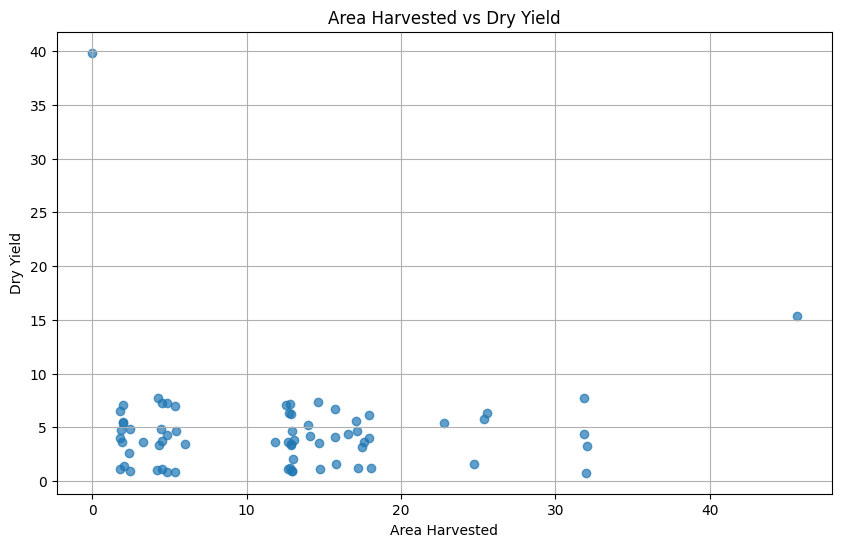

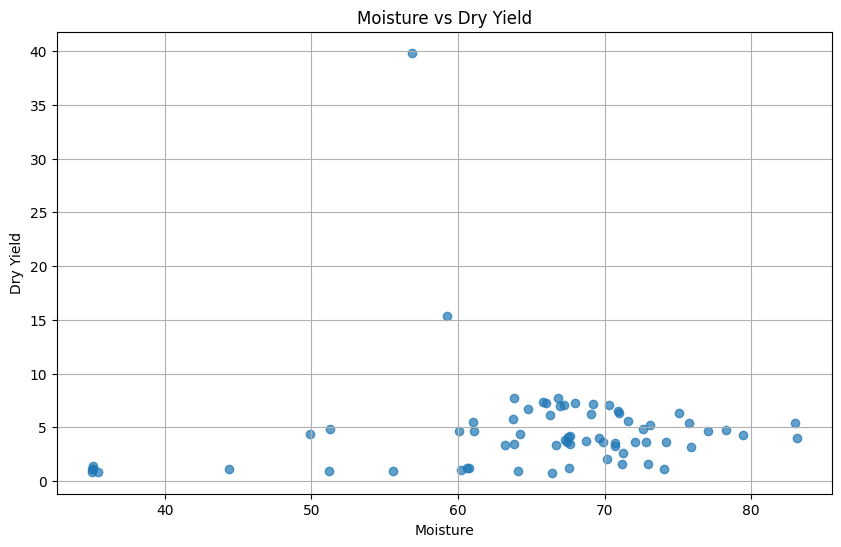

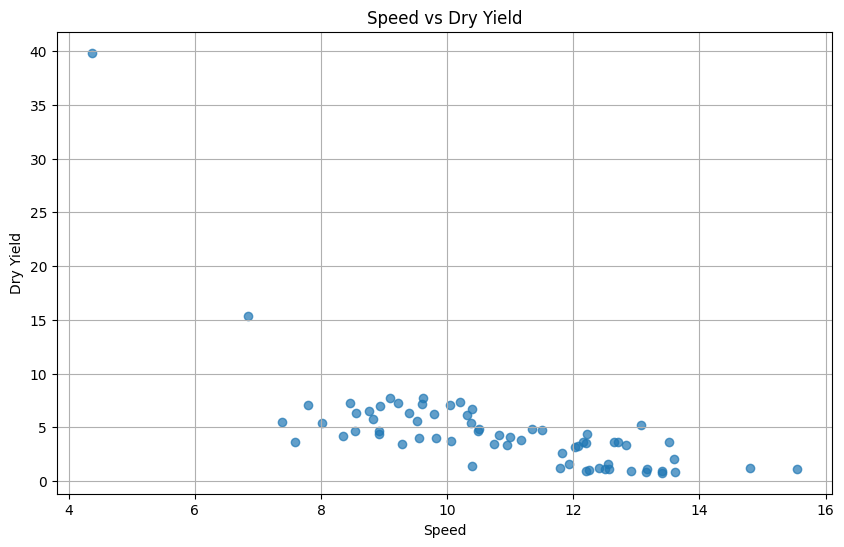

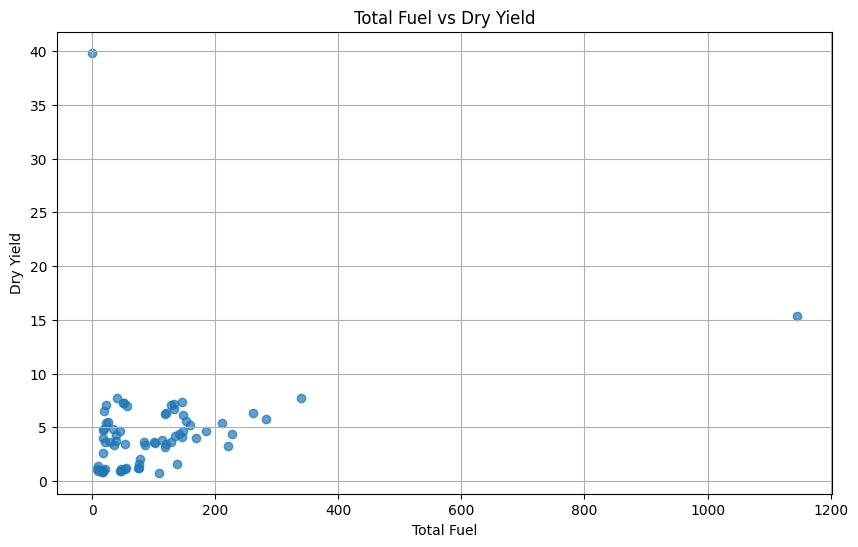

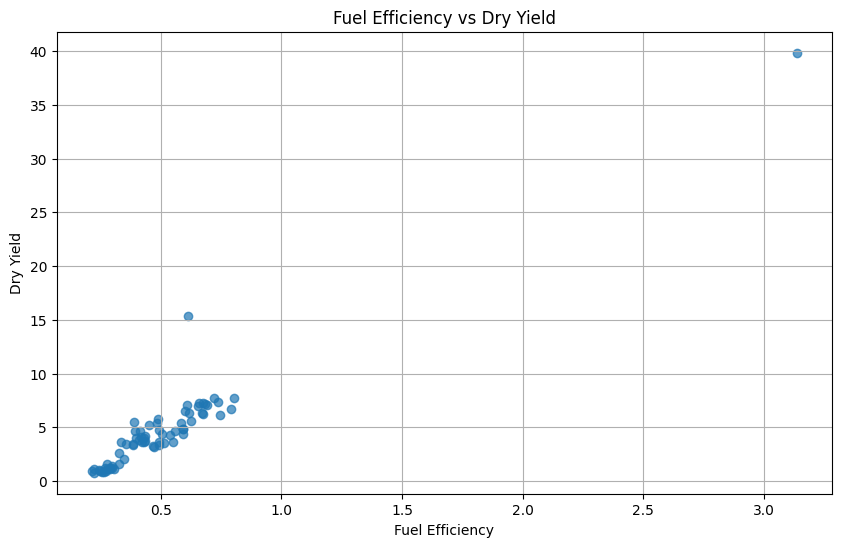

In [4]:
# Plot scatter plots for each feature against the target "Dry Yield"
for feature in features:
    plt.figure()
    plt.scatter(df_clean[feature], df_clean[target], alpha=0.7)
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{feature} vs {target}")
    plt.grid(True)
    plt.show()


# 4. Building the Regression Model

Here, the notebook details the process of constructing a predictive model:
- The cleaned data is split into training and testing sets.
- A Linear Regression model is initialized and trained using the training data.
- The model's performance is then evaluated on the testing set using metrics such as Mean Squared Error (MSE) and R-squared.
- This section forms the core of the yield prediction task by establishing a baseline regression model.


In [5]:
# Define X (features) and y (target)
X = df_clean[features]
y = df_clean[target]

# Split the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R-squared:", r2)


Model Evaluation:
Mean Squared Error (MSE): 0.4861285239480453
R-squared: 0.8900014478874234


# 5. Visualizing Model Predictions

After building the model, this section focuses on comparing the model's predictions to the actual values:
- A scatter plot is created where the actual "Dry Yield" values are plotted against the predicted values.
- A diagonal line is included to show the ideal prediction scenario, which helps visually assess the model's accuracy.
- This visualization is crucial for understanding how well the model performs and where improvements might be needed.


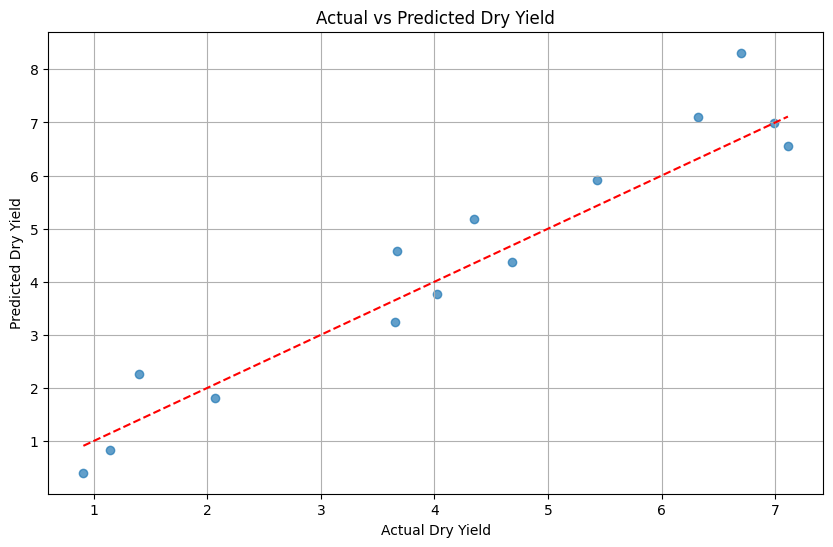

In [6]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Dry Yield")
plt.ylabel("Predicted Dry Yield")
plt.title("Actual vs Predicted Dry Yield")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.show()


# 6. Next Steps

The final section outlines further actions and enhancements:
- **Feature Engineering:** Consider exploring additional variables, such as harvest dates or machine types, and combining existing features for improved prediction accuracy.
- **Modeling Enhancements:** Experiment with advanced regression techniques (e.g., Random Forest, Gradient Boosting) and hyperparameter tuning.
- **Validation Techniques:** Implement cross-validation to further validate the model’s robustness.
- **Deployment:** Discuss integration strategies for incorporating the model into a real-time decision-support system for the farm.
- These steps provide a roadmap for refining the model and applying it to improve yield and productivity prediction.
